# Синтез управления: корневой годограф, регулятор и наблюдатель

Ноутбук к разделу «Синтез управления» главы 6. Примеры перенесены из MATLAB-версии курса (`20_Control1251s2.pdf`, `17_InvPend_exampl.m`, `31_InvPend_estim.m`).

Содержание:
1. Корневой годограф и выбор коэффициента обратной связи.
2. Перевёрнутый маятник с маховиком: регулятор с заданными полюсами (`ct.place`).
3. Наблюдатель и ошибка оценивания.
4. Регулятор по выходу (наблюдатель + обратная связь), принцип разделения.
5. Реакция на импульс, частотные характеристики, сингулярные числа.
6. Линейно-квадратичный регулятор и фильтр Калмана.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

np.set_printoptions(precision=4, suppress=True)

## 1. Корневой годограф

Объект — последовательное соединение колебательного звена и двух апериодических. Строим траектории полюсов замкнутой системы при изменении коэффициента $k$ в цепи обратной связи.

**Замечание к MATLAB-версии.** В исходном тексте матрица выхода звена `sys1` напечатана как `[1 0]`. Однако полюсы, приведённые там же ($-1.3116$, $-0.0511 \pm 1.1412i$, $-0.0195$ при $k = 38.19$), получаются только при `[0 1]`: выходом звена служит скорость. Ниже используется исправленная матрица, а в конце раздела проверен и напечатанный вариант.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


<TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                   s
  -----------------------------------
  30 s^4 + 43 s^3 + 44 s^2 + 14 s + 1


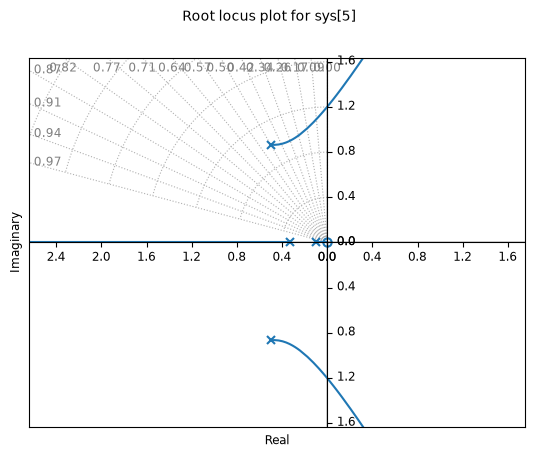

In [2]:
sys1 = ct.ss([[0, 1], [-1, -1]], [[0], [1]], [[0, 1]], 0)   # выход -- скорость
sys2 = ct.tf(1, [10, 1])
sys0 = ct.tf(1, [3, 1])
G = sys2 * sys1 * sys0
print(G)

ct.root_locus_plot(G)
plt.show()

Вместо MATLAB-функции `rlocfind` (выбор точки мышью) коэффициент для точки $s_0$ годографа вычисляется из условия $1 + k\,G(s_0) = 0$: $k = -1/G(s_0)$. Мнимая часть $k$ мала, если точка лежит на годографе (в пределах точности, с которой она выбрана).

In [3]:
s0 = -0.0650 + 1.1531j          # точка, выбранная в MATLAB-примере
k = -1 / G(s0)
print('k =', k)

k = 38.1893                      # значение, найденное rlocfind
print('полюсы замкнутой системы:', np.sort_complex(ct.feedback(G, k).poles()))

k = (38.13140584443373+2.1316662949747616j)
полюсы замкнутой системы: [-1.3116+0.j     -0.0511-1.1412j -0.0511+1.1412j -0.0195+0.j    ]


In [4]:
# проверка варианта, напечатанного в MATLAB-тексте: выход -- координата
sys1_printed = ct.ss([[0, 1], [-1, -1]], [[0], [1]], [[1, 0]], 0)
G_printed = sys2 * sys1_printed * sys0
print('полюсы при C = [1 0]:', np.sort_complex(ct.feedback(G_printed, 38.1893).poles()))

полюсы при C = [1 0]: [-0.9851-0.9095j -0.9851+0.9095j  0.2684-0.8091j  0.2684+0.8091j]


/private/tmp/claude-501/-Users-anko-Library-CloudStorage-Dropbox-anko--------------------------------------------------/c30a78e2-78b6-479e-becd-4504db93e209/scratchpad/venv/lib/python3.14/site-packages/scipy/signal/_filter_design.py:1234: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


## 2. Перевёрнутый маятник с маховиком

Маятник стабилизируется маховиком, который раскручивает двигатель. Вектор состояния $x = (\varphi, \dot\varphi, \theta, \dot\theta)^T$ — углы и угловые скорости маятника и маховика; управление $u$ — момент двигателя; измеряются оба угла. Параметры и формулы коэффициентов взяты из MATLAB-программы `17_InvPend_exampl.m`.

In [5]:
# параметры установки
M, m = 0.04, 0.312            # масса стержня и масса маховика, кг
Jm = 0.0000803                # момент инерции маховика, кг*м^2
c1, c2 = 0.0069, 0.000099     # коэффициенты двигателя
g, l = 9.8, 0.3
J = M * l**2 / 2

a1 = (M / 2 + m) / (J + m * l**2) * g * l
a2 = (J + m * l**2 + Jm) / (J + m * l**2) / Jm
c11, c21 = c1 / (J + m * l**2), c2 / (J + m * l**2)
c12, c22 = a2 * c1, a2 * c2

A = np.array([[0,   1, 0, 0],
              [a1,  0, 0, c21],
              [0,   0, 0, 1],
              [-a1, 0, 0, -c22]])
B = np.array([[0], [-c11], [0], [-c12]])
C = np.array([[1, 0, 0, 0],
              [0, 0, 1, 0]])
D = np.zeros((2, 1))

sys = ct.ss(A, B, C, D, inputs='u', outputs=['phi', 'theta'], name='pendulum')
print('полюсы разомкнутой системы:', np.linalg.eigvals(A))
print('ранг матрицы управляемости:', np.linalg.matrix_rank(ct.ctrb(A, B)))
print('ранг матрицы наблюдаемости:', np.linalg.matrix_rank(ct.obsv(A, C)))

полюсы разомкнутой системы: [ 0.    +0.j  5.7141+0.j -5.7176+0.j -1.2327+0.j]
ранг матрицы управляемости: 4
ранг матрицы наблюдаемости: 4


Система неустойчива (есть положительный полюс), но вполне управляема и вполне наблюдаема. Зададим полюсы замкнутой системы и найдём коэффициенты обратной связи $u = -Kx$.

In [6]:
K = ct.place(A, B, [-1, -1.5, -5.7, -5])
print('K =', K)
print('собственные числа A - BK:', np.sort(np.linalg.eigvals(A - B @ K)))

K = [[-274.2565  -47.9734    0.0151   -0.0103]]
собственные числа A - BK: [-5.7+0.j -5. +0.j -1.5+0.j -1. +0.j]


## 3. Наблюдатель

Матрица $L$ наблюдателя выбирается так, чтобы собственные числа $A - LC$ приняли заданные значения. Так как они совпадают с собственными числами $A^T - C^T L^T$, используется та же функция `ct.place` для двойственной системы. (В Octave-программе результат `place` хранился транспонированным и использовался как `L'`.)

In [7]:
L = ct.place(A.T, C.T, [-1, -1.5, -5.7, -1.01]).T     # матрица 4 x 2
print('собственные числа A - LC:', np.sort(np.linalg.eigvals(A - L @ C)))

собственные числа A - LC: [-5.7 +0.j -1.5 +0.j -1.01+0.j -1.  +0.j]


Исследуем сам наблюдатель (программа `31_InvPend_estim.m`): соединим объект и наблюдатель последовательно, а выходом сделаем ошибку оценивания $x - \tilde x$. Здесь наблюдатель получает только измерения $y$, поэтому такой анализ корректен при $u = 0$: проверяем, как затухает ошибка из-за неверного начального значения оценки.

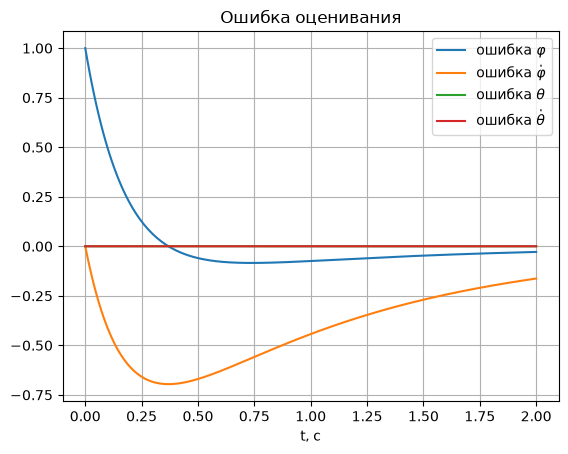

In [8]:
est = ct.ss(A - L @ C, L, np.eye(4), np.zeros((4, 2)))
ser = ct.series(sys, est)          # состояния: сначала объект, затем наблюдатель
err = ct.ss(ser.A, ser.B, np.hstack([np.eye(4), -np.eye(4)]), np.zeros((4, 1)))

T = np.linspace(0, 2, 201)          # как в MATLAB-программе
r = ct.initial_response(err, T, X0=[1, 0, 0, 0, 0, 0, 0, 0])
names = [r'$\varphi$', r'$\dot\varphi$', r'$\theta$', r'$\dot\theta$']
for i in range(4):
    plt.plot(r.time, r.outputs[i], label='ошибка ' + names[i])
plt.xlabel('t, с')
plt.legend()
plt.grid(True)
plt.title('Ошибка оценивания')
plt.show()

**Осторожно: численная ловушка.** Объект неустойчив, поэтому и $x$, и $\tilde x$ растут экспоненциально (примерно как $e^{5.7t}$), а ошибка вычисляется как разность двух близких больших чисел. На интервале 2 с это не страшно, но уже к $t = 6$ с к $x$ и $\tilde x$ порядка $10^{14}$, и от разности остаётся шум. Надёжнее сразу записать уравнение для ошибки: $\dot e = (A - LC)e + Bu$. В нём неустойчивые движения объекта не участвуют.

t = 6 с, ошибка как разность x - x~: [0.3125 1.5    0.4375 1.25  ]
t = 6 с, по уравнению для ошибки:   [-0.0005 -0.0029 -0.      0.    ]


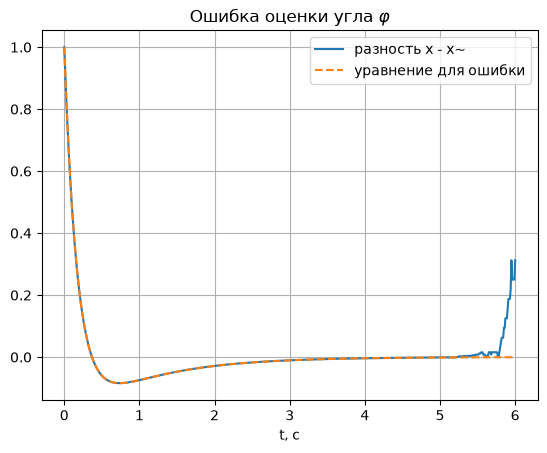

In [9]:
err_direct = ct.ss(A - L @ C, B, np.eye(4), np.zeros((4, 1)))   # уравнение для ошибки

T6 = np.linspace(0, 6, 601)
r_diff = ct.initial_response(err, T6, X0=[1, 0, 0, 0, 0, 0, 0, 0])
r_dir = ct.initial_response(err_direct, T6, X0=[1, 0, 0, 0])
print('t = 6 с, ошибка как разность x - x~:', r_diff.outputs[:, -1])
print('t = 6 с, по уравнению для ошибки:  ', r_dir.outputs[:, -1])

plt.plot(T6, r_diff.outputs[0], label='разность x - x~')
plt.plot(T6, r_dir.outputs[0], '--', label='уравнение для ошибки')
plt.xlabel('t, с')
plt.title(r'Ошибка оценки угла $\varphi$')
plt.legend()
plt.grid(True)
plt.show()

## 4. Регулятор по выходу

Регулятор получает измерения $y$, формирует оценку $\tilde x$ и управление $u = -K\tilde x$:
$$
\dot{\tilde x} = \bigl(A - LC - (B - LD)K\bigr)\tilde x + L y .
$$
Замыкаем объект этим регулятором по отрицательной обратной связи (в MATLAB — `feedback(sys, K*est, -1)`).

In [10]:
An = A - L @ C - (B - L @ D) @ K
reg = ct.ss(An, L, K, np.zeros((1, 2)), name='regulator')
cl = ct.feedback(sys, reg, sign=-1)
print('полюсы замкнутой системы:', np.sort_complex(cl.poles()))

полюсы замкнутой системы: [-5.7 -0.j -5.7 +0.j -5.  +0.j -1.5 -0.j -1.5 +0.j -1.01+0.j -1.  -0.j
 -1.  +0.j]


Полюсы замкнутой системы — объединение полюсов регулятора ($-1, -1.5, -5.7, -5$) и наблюдателя ($-1, -1.5, -5.7, -1.01$): это **принцип разделения**.

## 5. Реакция на импульс и частотные характеристики

форма outputs: (2, 1, 201) (выходы, входы, моменты времени)


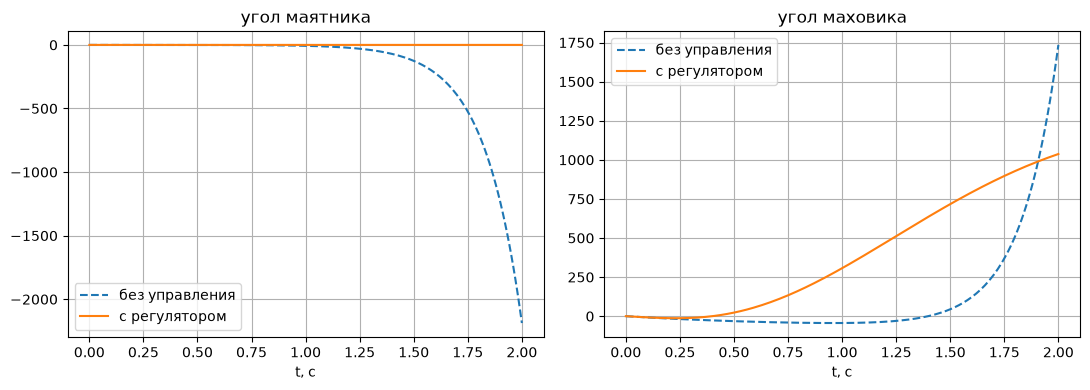

In [11]:
T = np.linspace(0, 2, 201)
r_open = ct.impulse_response(sys, T)
r_cl = ct.impulse_response(cl, T)
print('форма outputs:', r_cl.outputs.shape, '(выходы, входы, моменты времени)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, i, name in zip(axes, [0, 1], ['угол маятника', 'угол маховика']):
    ax.plot(T, r_open.outputs[i, 0], '--', label='без управления')
    ax.plot(T, r_cl.outputs[i, 0], label='с регулятором')
    ax.set_title(name)
    ax.set_xlabel('t, с')
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()

Частотные характеристики имеют смысл для асимптотически устойчивой системы, поэтому строим их для замкнутой системы. Запись `cl[0, 0]` выделяет канал «выход 0 — вход 0» (в MATLAB — `syscl(1,1)`).

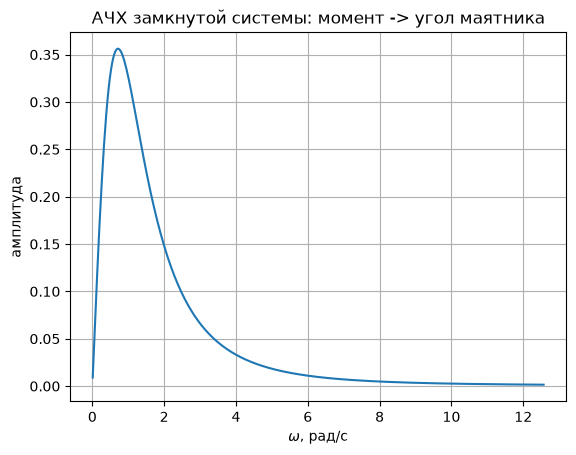

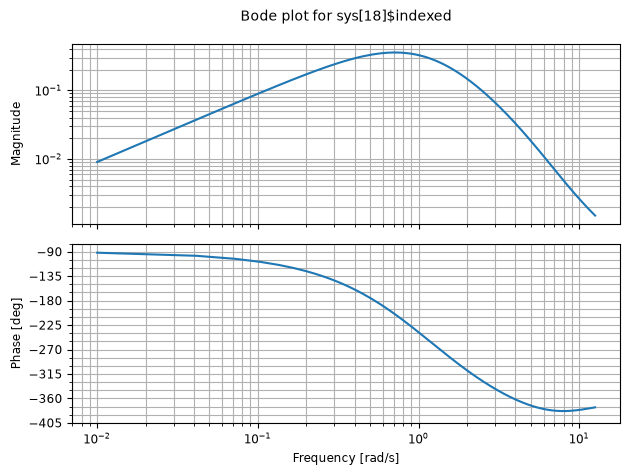

In [12]:
w = np.linspace(0.01, 4 * np.pi, 400)
fr = ct.frequency_response(cl[0, 0], w)
plt.plot(w, fr.magnitude)
plt.xlabel(r'$\omega$, рад/с')
plt.ylabel('амплитуда')
plt.title('АЧХ замкнутой системы: момент -> угол маятника')
plt.grid(True)
plt.show()

ct.bode_plot(cl[0, 0], w)
plt.show()

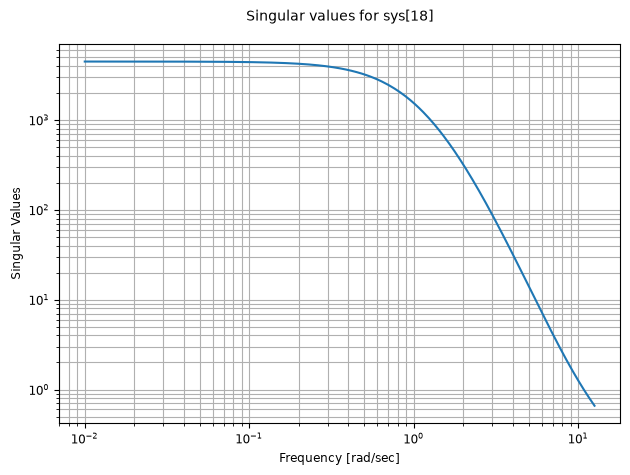

In [13]:
# сингулярные числа частотной матрицы (аналог sigma в MATLAB)
ct.singular_values_plot(cl, w)
plt.show()

## 6. Линейно-квадратичный регулятор и фильтр Калмана

Вместо заданных полюсов можно минимизировать квадратичный функционал $\int (x^TQx + u^TRu)\,dt$ (`ct.lqr`) и выбрать наблюдатель как фильтр Калмана (`ct.lqe`). Шум процесса считаем приложенным ко входу ($G = B$), интенсивности шумов — единичная для процесса и 0.01 для измерений. Веса $Q$ и $R$ подобраны для примера; попробуйте их изменить.

K_lqr = [[-1766.4817  -308.7239     1.         0.3577]]
полюсы A - B K_lqr: [-27.0853+0.j      -5.7234-0.0225j  -5.7234+0.0225j  -3.1806+0.j    ]
полюсы фильтра Калмана: [-20.7638-20.7475j -20.7638+20.7475j  -5.7231 -0.0069j  -5.7231 +0.0069j]
устойчива: True


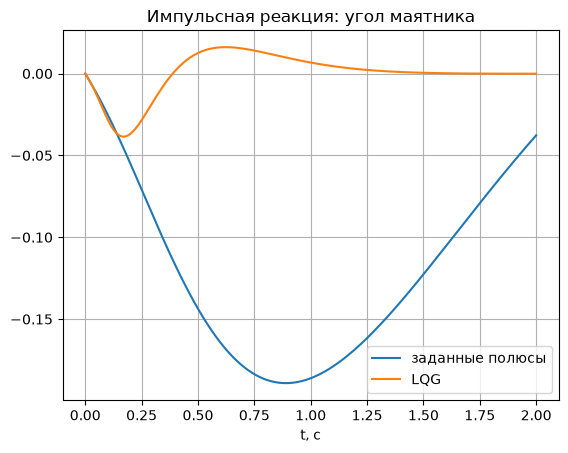

In [14]:
Q = np.diag([10, 1, 1, 0.1])
R = np.array([[1.0]])
K_lqr, S, E = ct.lqr(A, B, Q, R)
print('K_lqr =', K_lqr)
print('полюсы A - B K_lqr:', np.sort_complex(E))

L_kf, P, E_kf = ct.lqe(A, B, C, np.eye(1), 0.01 * np.eye(2))
print('полюсы фильтра Калмана:', np.sort_complex(E_kf))

# LQG-регулятор собирается так же, как в п. 4
An = A - L_kf @ C - (B - L_kf @ D) @ K_lqr
reg_lqg = ct.ss(An, L_kf, K_lqr, np.zeros((1, 2)))
cl_lqg = ct.feedback(sys, reg_lqg, sign=-1)
print('устойчива:', np.all(cl_lqg.poles().real < 0))

r_lqg = ct.impulse_response(cl_lqg, T)
plt.plot(T, r_cl.outputs[0, 0], label='заданные полюсы')
plt.plot(T, r_lqg.outputs[0, 0], label='LQG')
plt.xlabel('t, с')
plt.title('Импульсная реакция: угол маятника')
plt.legend()
plt.grid(True)
plt.show()

**Что попробовать:**
- сдвиньте желаемые полюсы регулятора левее (например, до $-20$) и сравните коэффициенты $K$ и реакцию;
- сделайте наблюдатель медленнее регулятора и посмотрите, как это сказывается на импульсной реакции;
- измеряйте только угол маятника ($C$ — одна строка): останется ли система наблюдаемой?

## Дополнения из MATLAB-программ

**Как в `17_InvPend_exampl.m`:** сравнение АЧХ разомкнутой и замкнутой систем и сингулярные числа обеих систем. Разомкнутая система неустойчива, поэтому её частотная характеристика не описывает установившиеся колебания: это лишь значения $|G(i\omega)|$, их удобно сравнивать с замкнутой системой.

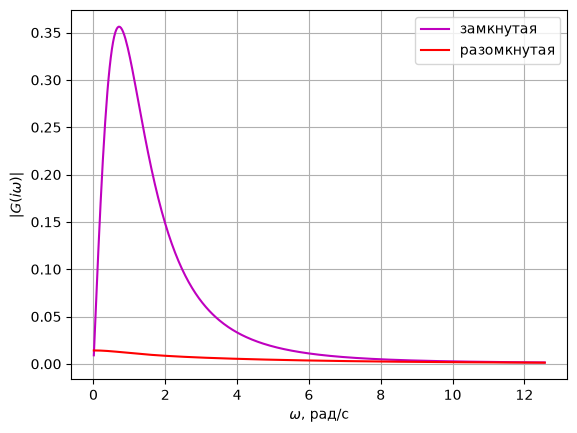

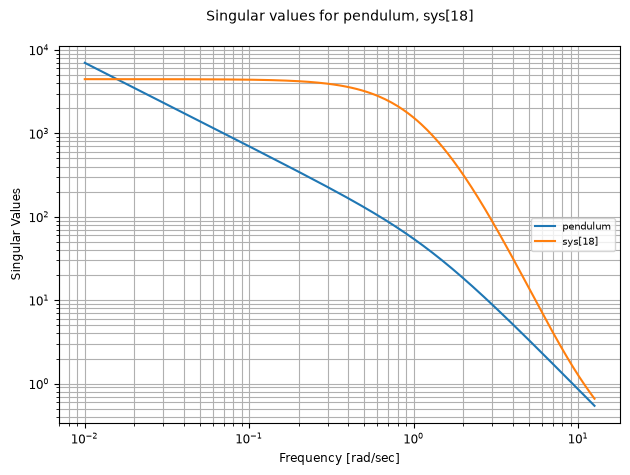

In [15]:
w = np.linspace(0.01, 4 * np.pi, 400)
plt.plot(w, ct.frequency_response(cl[0, 0], w).magnitude, 'm', label='замкнутая')
plt.plot(w, ct.frequency_response(sys[0, 0], w).magnitude, 'r', label='разомкнутая')
plt.xlabel(r'$\omega$, рад/с')
plt.ylabel(r'$|G(i\omega)|$')
plt.legend()
plt.grid(True)
plt.show()

ct.singular_values_plot([sys, cl], w)
plt.show()

**Как в `31_InvPend_estim.m`:** импульсная реакция и АЧХ системы «объект + наблюдатель» с выходом «ошибка оценивания». Импульс во вход объекта, который наблюдатель не получает, создаёт ошибку оценивания; она затухает с темпом, заданным полюсами наблюдателя.

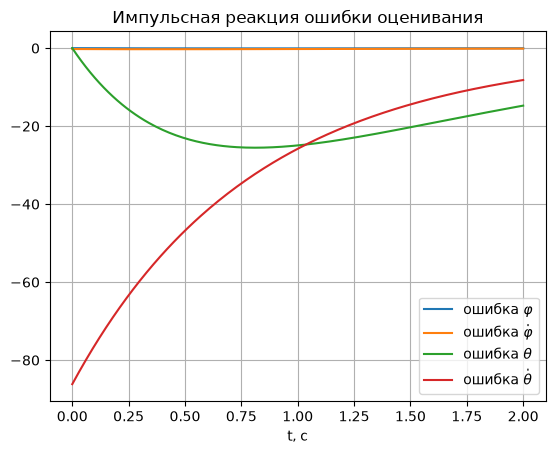

полюсы системы «объект + наблюдатель»: [-5.7176+0.j -5.7   +0.j -1.5   +0.j -1.2327+0.j -1.01  +0.j -1.    +0.j
  0.    +0.j  5.7141+0.j]


In [16]:
T = np.linspace(0, 2, 201)
r = ct.impulse_response(err, T)
for i in range(4):
    plt.plot(r.time, r.outputs[i, 0], label='ошибка ' + names[i])
plt.xlabel('t, с')
plt.title('Импульсная реакция ошибки оценивания')
plt.legend()
plt.grid(True)
plt.show()

print('полюсы системы «объект + наблюдатель»:', np.sort_complex(err.poles()))